In [9]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
from datasets import Dataset
from PIL import Image
from transformers import ViTForImageClassification, ViTImageProcessor, Trainer, TrainingArguments
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_auc_score

In [ ]:
model = ViTForImageClassification.from_pretrained("../vit-finetuned-model")
processor = ViTImageProcessor.from_pretrained("../vit-finetuned-model")

training_args = TrainingArguments(
    output_dir="./tmp",
    per_device_eval_batch_size=16,
    dataloader_num_workers=0,
    remove_unused_columns=False,
)
trainer = Trainer(model=model, args=training_args)

Loading weights: 100%|██████████| 200/200 [00:00<00:00, 6687.61it/s]


In [ ]:
def make_hf_dataset(df_split):  #got this from claude
    def load_example(example):
        img = Image.open(example["path"]).convert("RGB")
        inputs = processor(img, return_tensors="pt")
        return {"pixel_values": inputs["pixel_values"].squeeze(0), "labels": example["label"]}
    ds = Dataset.from_dict({"path": df_split["path"].tolist(), "label": df_split["label"].tolist()})
    return ds.map(load_example, remove_columns=["path"]).with_format("torch")

df_og  = pd.read_csv("../../chest_xray/xray_og/original_dataset.csv")
df_trans = pd.read_csv("../../chest_xray/xray_transformed/transform_dataset.csv")

test_og = df_og[df_og["split"] == "test"]
test_trans = df_trans[df_trans["split"] == "test"]

hf_test_og = make_hf_dataset(test_og)
hf_test_trans = make_hf_dataset(test_trans)

Map: 100%|██████████| 624/624 [00:07<00:00, 79.18 examples/s] 


/Users/zubair/Desktop/ada_final_project/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



── ViT (Original Dataset, threshold=0.9) ──
              precision    recall  f1-score   support

      NORMAL       1.00      0.36      0.53       234
   PNEUMONIA       0.72      1.00      0.84       390

    accuracy                           0.76       624
   macro avg       0.86      0.68      0.69       624
weighted avg       0.83      0.76      0.72       624


── ViT (Transformed Dataset, threshold=0.9) ──
              precision    recall  f1-score   support

      NORMAL       0.99      0.47      0.63       234
   PNEUMONIA       0.76      1.00      0.86       390

    accuracy                           0.80       624
   macro avg       0.87      0.73      0.75       624
weighted avg       0.84      0.80      0.78       624



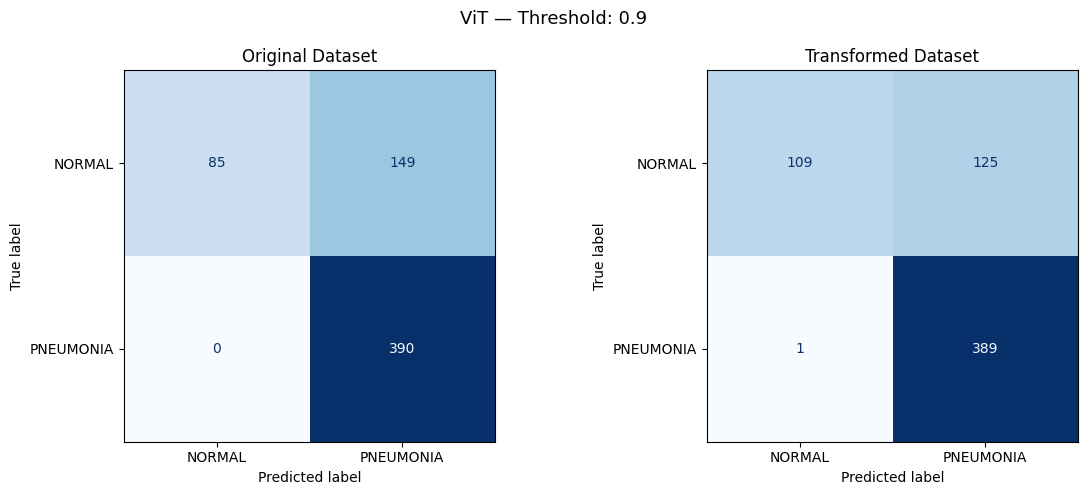

In [ ]:
import numpy as np

output_og = trainer.predict(hf_test_og)
output_trans = trainer.predict(hf_test_trans)

probs_og = torch.softmax(torch.tensor(output_og.predictions),    dim=1)[:, 1].numpy()
probs_trans = torch.softmax(torch.tensor(output_trans.predictions), dim=1)[:, 1].numpy()
y_true_og = output_og.label_ids
y_true_trans = output_trans.label_ids

best_threshold = 0.9 

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f"ViT — Threshold: {best_threshold}", fontsize=13)

for ax, probs, y_true, title in [
    (axes[0], probs_og, y_true_og, "Original Dataset"),
    (axes[1], probs_trans, y_true_trans, "Transformed Dataset"),
]:
    y_pred = (probs >= best_threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["NORMAL", "PNEUMONIA"])
    disp.plot(cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(title)
    print(f"\n── ViT ({title}, threshold={best_threshold}) ──")
    print(classification_report(y_true, y_pred, target_names=["NORMAL", "PNEUMONIA"]))

plt.tight_layout()
plt.savefig("CM/vit_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()